# Домашнее задание: Visual Question Answering (VQA)

## 1. Введение

### Что такое VQA?

**Visual Question Answering (VQA)** — задача, в которой модель должна ответить на текстовый вопрос об изображении. Например:
- Изображение: фотография кота
- Вопрос: "Какого цвета кот?"
- Ответ: "Рыжий"

Это мультимодальная задача, требующая понимания как визуальной, так и текстовой информации

### Зачем нужны мультимодальные модели?

Традиционные модели работают либо с изображениями, либо с текстом. Мультимодальные модели объединяют оба типа данных:
- **Простой подход:** объединение эмбеддингов из разных моделей (ResNet + T5)
- **Продвинутый подход:** сквозное обучение (CLIP, LLaVA)

## 2. Подготовка окружения

Установим необходимые библиотеки для работы с моделями и интерфейсами.

In [3]:
!pip install -q torch torchvision transformers open_clip_torch gradio pillow pandas accelerate bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.8 MB/s eta 0:00:00


In [6]:
import torch
import torchvision
from torchvision import transforms, models
from transformers import T5EncoderModel, T5Tokenizer, CLIPProcessor, CLIPModel
from transformers import AutoProcessor, LlavaForConditionalGeneration
import open_clip
import gradio as gr
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from torch import nn
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Память: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

from torchvision.datasets import CIFAR10


Используемое устройство: cuda
   GPU: Tesla T4
   Память: 15.83 GB


## 3. Подготовка данных

Создадим небольшой датасет для тестирования. Для простоты возьмем несколько изображений из CIFAR-10 и составим вопросы вручную

### Задание 3.1: Загрузите датасет CIFAR-10

**Что нужно сделать:**
- Загрузите тестовую часть CIFAR-10 (используйте `torchvision.datasets.CIFAR10`)
- Выберите 5-7 изображений из разных классов
- Сохраните их в список `sample_images`

In [7]:
cifar_dataset = CIFAR10(
    root='./data',
    train=False,
    download=True
)

sample_images = []    # Список PIL изображений
sample_labels = []    # Список меток классов

# Имена классов CIFAR-10
cifar_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                 'dog', 'frog', 'horse', 'ship', 'truck']

# Ваш код здесь: выберите по одному изображению из разных классов
selected_classes = set()

for img, label in cifar_dataset:
    if label not in selected_classes:
        sample_images.append(img)
        sample_labels.append(label)
        selected_classes.add(label)
    if len(selected_classes) >= 6:
        break

print("Выбранные классы:")
for lbl in sample_labels:
    print(cifar_classes[lbl])

100%|██████████| 170M/170M [00:04<00:00, 34.4MB/s]


Выбранные классы:
cat
ship
airplane
frog
automobile
truck


### Задание 3.2: Создайте DataFrame с вопросами и ответами

**Что нужно сделать:**
- Для каждого изображения придумайте 1-2 вопроса
- Вопросы могут быть о: цвете, типе объекта, количестве объектов, действиях
- Создайте pandas DataFrame с колонками: `image_id`, `question`, `answer`

In [8]:
qa_data = {
    'image_id': [],
    'question': [],
    'answer': []
}

for idx, label in enumerate(sample_labels):
    class_name = cifar_classes[label]

    qa_data['image_id'].append(idx)
    qa_data['question'].append("What object is shown in the image?")
    qa_data['answer'].append(class_name)

    qa_data['image_id'].append(idx)
    qa_data['question'].append(f"Is there a {class_name} in the image?")
    qa_data['answer'].append("yes")

df = pd.DataFrame(qa_data)

print(f"\nСоздан датасет: {len(df)} вопросов для {len(sample_images)} изображений")
print(df.head())



Создан датасет: 12 вопросов для 6 изображений
   image_id                            question    answer
0         0  What object is shown in the image?       cat
1         0        Is there a cat in the image?       yes
2         1  What object is shown in the image?      ship
3         1       Is there a ship in the image?       yes
4         2  What object is shown in the image?  airplane


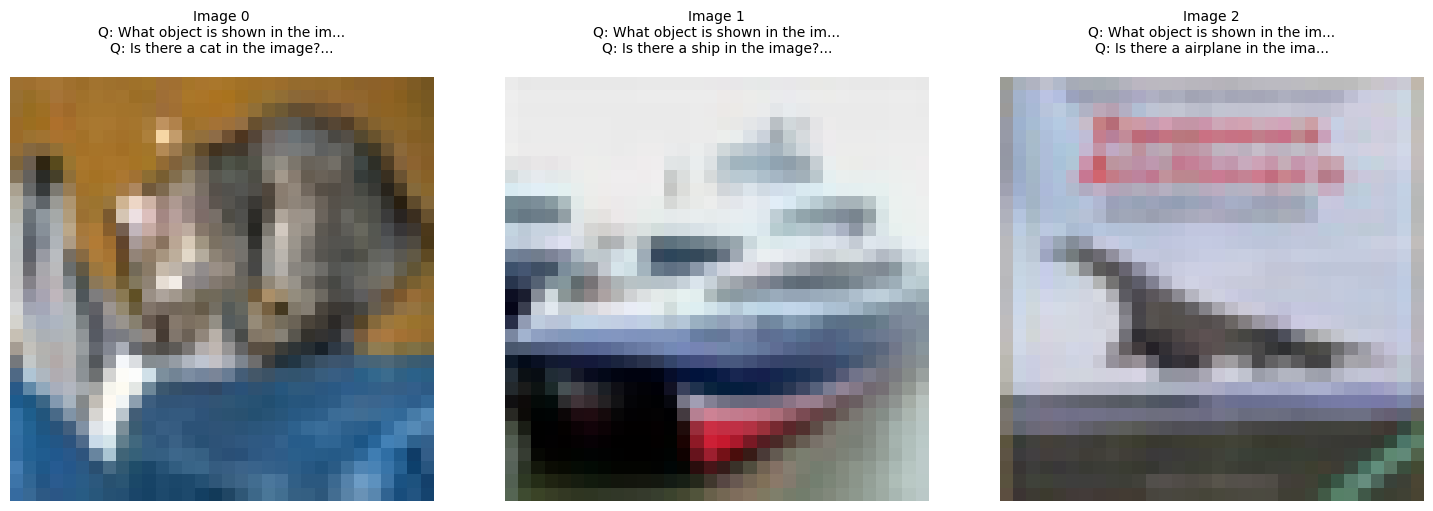

In [10]:
def visualize_samples(images, df, n_samples=3):
    fig, axes = plt.subplots(1, min(n_samples, len(images)), figsize=(15, 5))
    if n_samples == 1:
        axes = [axes]

    for idx, ax in enumerate(axes):
        if idx < len(images):
            ax.imshow(images[idx])
            ax.axis('off')
            questions = df[df['image_id'] == idx]
            title = f"Image {idx}\n"
            for _, row in questions.iterrows():
                title += f"Q: {row['question'][:30]}...\n"
            ax.set_title(title, fontsize=10)
    plt.tight_layout()
    plt.show()
visualize_samples(sample_images, df, n_samples=3)

## 4. Baseline: ResNet + T5

Создадим простой бейз, который:
1. Извлекает эмбеддинги изображений через предобученный ResNet50
2. Извлекает эмбеддинги вопросов через T5-small
3. Объединяет их и предсказывает ответ через MLP

### Задание 4.1: Извлеките эмбеддинги изображений

**Что нужно сделать:**
- Загрузите предобученный ResNet50
- Удалите последний слой классификации (голову)
- Извлеките эмбеддинги для всех изображений

In [11]:
class ImageEncoder:
    def __init__(self):
        resnet = models.resnet50(pretrained=True)
        self.model = nn.Sequential(*list(resnet.children())[:-1])
        self.model.to(device)
        self.model.eval()

        self.transform = transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

    def encode(self, images):
        tensors = torch.stack([
            self.transform(img) for img in images
        ]).to(device)

        with torch.no_grad():
            embeddings = self.model(tensors)
            embeddings = embeddings.squeeze(-1).squeeze(-1)

        return embeddings


image_encoder = ImageEncoder()
image_embeddings = image_encoder.encode(sample_images)

print(f"Размерность эмбеддингов изображений: {image_embeddings.shape}")


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 182MB/s]


Размерность эмбеддингов изображений: torch.Size([6, 2048])


### Задание 4.2: Извлеките эмбеддинги вопросов

**Что нужно сделать:**
- Загрузите T5-small encoder и tokenizer
- Токенизируйте все вопросы
- Получите эмбеддинги (используйте mean pooling по последней скрытой размерности)

In [12]:
class TextEncoder:
    def __init__(self, model_name='t5-small'):
        self.tokenizer = T5Tokenizer.from_pretrained(model_name)
        self.model = T5EncoderModel.from_pretrained(model_name)
        self.model.to(device)
        self.model.eval()

    def encode(self, texts):
        tokens = self.tokenizer(
            texts,
            padding=True,
            truncation=True,
            return_tensors='pt'
        ).to(device)

        with torch.no_grad():
            outputs = self.model(**tokens)
            hidden_states = outputs.last_hidden_state
            embeddings = hidden_states.mean(dim=1)

        return embeddings


text_encoder = TextEncoder()
question_embeddings = text_encoder.encode(df['question'].tolist())

print(f'Размерность эмбеддингов вопросов: {question_embeddings.shape}')


tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Размерность эмбеддингов вопросов: torch.Size([12, 512])


### Задание 4.3: Обучите MLP-классификатор

**Что нужно сделать:**
- Объедините эмбеддинги изображений и вопросов (конкатенация)
- Создайте словарь всех уникальных ответов
- Реализуйте простой MLP (2-3 слоя)
- Обучите модель на нескольких эпохах

**Примечание:** Из-за маленького датасета не ожидайте высокую точность. Цель — понять архитектуру.

In [13]:
class VQAClassifier(nn.Module):
    def __init__(self, image_dim, text_dim, num_classes, hidden_dim=512):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(image_dim + text_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, num_classes)
        )

    def forward(self, image_emb, text_emb):
        x = torch.cat([image_emb, text_emb], dim=1)
        return self.fc(x)


In [14]:
answer_vocab = {ans: idx for idx, ans in enumerate(df['answer'].unique())}
idx_to_answer = {idx: ans for ans, idx in answer_vocab.items()}

print(f"\nСловарь ответов ({len(answer_vocab)} классов): {list(answer_vocab.keys())}")


Словарь ответов (7 классов): ['cat', 'yes', 'ship', 'airplane', 'frog', 'automobile', 'truck']


In [15]:
img_embs = []
for img_id in df['image_id']:
    img_embs.append(image_embeddings[img_id])

img_embs = torch.stack(img_embs).to(device)

text_embs = question_embeddings.to(device)

labels = torch.tensor(
    [answer_vocab[a] for a in df['answer']],
    dtype=torch.long
).to(device)


In [16]:
model = VQAClassifier(
    image_dim=image_embeddings.shape[1],
    text_dim=question_embeddings.shape[1],
    num_classes=len(answer_vocab)
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

epochs = 7

for epoch in range(epochs):
    model.train()

    optimizer.zero_grad()
    outputs = model(img_embs, text_embs)
    loss = criterion(outputs, labels)

    loss.backward()
    optimizer.step()

    preds = outputs.argmax(dim=1)
    acc = (preds == labels).float().mean().item()

    print(f"Epoch [{epoch+1}/{epochs}] | Loss: {loss.item():.4f} | Acc: {acc:.2f}")

Epoch [1/7] | Loss: 1.9824 | Acc: 0.08
Epoch [2/7] | Loss: 1.6370 | Acc: 0.50
Epoch [3/7] | Loss: 1.6224 | Acc: 0.50
Epoch [4/7] | Loss: 1.5339 | Acc: 0.50
Epoch [5/7] | Loss: 1.3957 | Acc: 0.50
Epoch [6/7] | Loss: 1.2717 | Acc: 0.50
Epoch [7/7] | Loss: 1.2145 | Acc: 0.50


### Задание 4.4: Протестируйте baseline

**Что нужно сделать:**
- Выберите 2-3 примера из датасета
- Получите предсказания модели
- Выведите изображение, вопрос, истинный и предсказанный ответ

In [17]:
def predict_baseline(image_id, question):
    model.eval()

    img_emb = image_embeddings[image_id].unsqueeze(0).to(device)

    text_emb = text_encoder.encode([question]).to(device)

    with torch.no_grad():
        logits = model(img_emb, text_emb)
        pred_idx = logits.argmax(dim=1).item()

    return idx_to_answer[pred_idx]


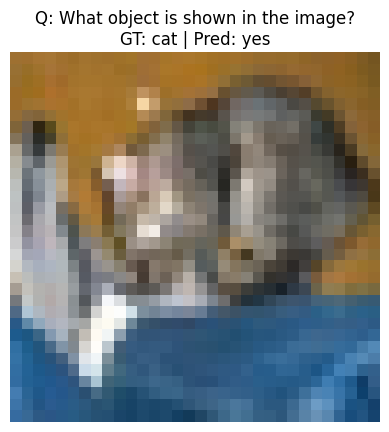

In [18]:
sample_id = 0
sample_question = df.iloc[0]['question']
true_answer = df.iloc[0]['answer']

pred_answer = predict_baseline(sample_id, sample_question)

plt.imshow(sample_images[sample_id])
plt.axis('off')
plt.title(f"Q: {sample_question}\nGT: {true_answer} | Pred: {pred_answer}")
plt.show()


## 5. CLIP Zero-Shot Baseline

CLIP — это мультимодальная модель, обученная связывать изображения и тексты. Мы используем её для zero-shot VQA:
1. Для каждой пары (изображение, вопрос) сформируем набор возможных ответов
2. Составим промпты типа "A photo of {answer}"
3. CLIP выберет наиболее вероятный ответ

### Задание 5.1: Загрузите CLIP

**Что нужно сделать:**
- Загрузите CLIP модель (используйте `openai/clip-vit-base-patch32` через transformers)
- Или используйте `open_clip` библиотеку

In [19]:
clip_model = CLIPModel.from_pretrained(
    'openai/clip-vit-base-patch32'
).to(device)
clip_processor = CLIPProcessor.from_pretrained(
    'openai/clip-vit-base-patch32'
)

clip_model.eval()


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

### Задание 5.2: Реализуйте zero-shot VQA с CLIP

**Что нужно сделать:**
- Для каждого изображения и вопроса создайте список возможных ответов (используйте answer_vocab)
- Сформируйте промпты: \"Question: {question}. Answer: {answer}\"
- Используйте CLIP для выбора наиболее подходящего ответа

In [20]:
import torch.nn.functional as F

def predict_clip(image, question, candidate_answers):
    prompts = [
        f"Question: {question}. Answer: {ans}"
        for ans in candidate_answers
    ]

    inputs = clip_processor(
        text=prompts,
        images=image,
        return_tensors='pt',
        padding=True
    ).to(device)

    with torch.no_grad():
        outputs = clip_model(**inputs)
        img_emb = outputs.image_embeds
        text_emb = outputs.text_embeds

    img_emb = F.normalize(img_emb, dim=-1)
    text_emb = F.normalize(text_emb, dim=-1)

    sims = img_emb @ text_emb.T
    best_idx = sims.argmax(dim=1).item()

    return candidate_answers[best_idx]


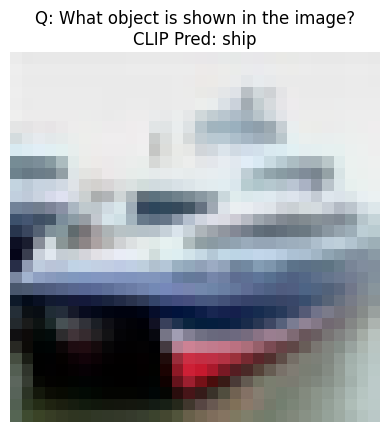

In [21]:
candidate_answers = list(answer_vocab.keys())

img_id = 1
question = df.iloc[2]['question']

pred_clip = predict_clip(
    sample_images[img_id],
    question,
    candidate_answers
)

plt.imshow(sample_images[img_id])
plt.axis('off')
plt.title(f"Q: {question}\nCLIP Pred: {pred_clip}")
plt.show()


## 6. LLaVA Inference

LLaVA (Large Language and Vision Assistant) — это большая мультимодальная модель, которая может генерировать текстовые ответы на вопросы об изображениях.

**Внимание:** LLaVA-1.5-7B требует ~14GB GPU памяти. Если в Colab недостаточно памяти, используйте квантизацию (8-bit) или напишите мне про датасферу.

### Задание 6.1: Загрузите LLaVA

**Что нужно сделать:**
- Загрузите модель `llava-hf/llava-1.5-7b-hf`
- При необходимости используйте квантизацию для экономии памяти

In [22]:
from transformers import BitsAndBytesConfig

quantization_config = BitsAndBytesConfig(
    load_in_8bit=True,
    bnb_8bit_compute_dtype=torch.float16
)

llava_model = LlavaForConditionalGeneration.from_pretrained(
    "llava-hf/llava-1.5-7b-hf",
    quantization_config=quantization_config,
    device_map="auto"
)

llava_processor = AutoProcessor.from_pretrained(
    "llava-hf/llava-1.5-7b-hf"
)

llava_model.eval()
print("LLaVA загружена")


config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/4.18G [00:00<?, ?B/s]

model-00001-of-00003.safetensors:   0%|          | 0.00/4.99G [00:00<?, ?B/s]

...

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/41.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/552 [00:00<?, ?B/s]

LLaVA загружена


### Задание 6.2: Генерация ответов с LLaVA

**Что нужно сделать:**
- Реализуйте функцию для генерации ответов
- Используйте формат промпта: "USER: <image>
Question: {question}
ASSISTANT:"
- Протестируйте на 2-3 примерах

In [27]:
def predict_llava(image, question, max_new_tokens=50):
    """
    Генерирует ответ с помощью LLaVA.

    Args:
        image: PIL Image
        question: строка с вопросом

    Returns:
        answer: сгенерированный ответ
    """

    prompt = f"USER: <image>\nQuestion: {question}\nASSISTANT:"

    inputs = llava_processor(
        text=prompt,
        images=image,
        return_tensors="pt"
    )

    inputs = {k: v.to(llava_model.device) for k, v in inputs.items()}

    with torch.no_grad():
        output_ids = llava_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False
        )

    output_text = llava_processor.batch_decode(
        output_ids,
        skip_special_tokens=True
    )[0]

    answer = output_text.split("ASSISTANT:")[-1].strip()

    return answer

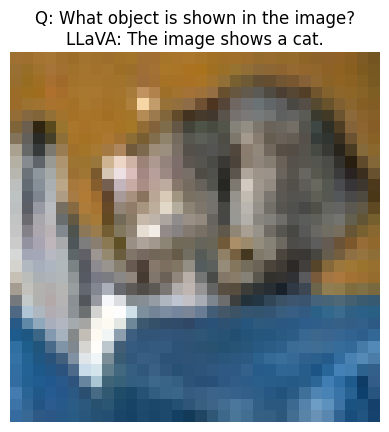

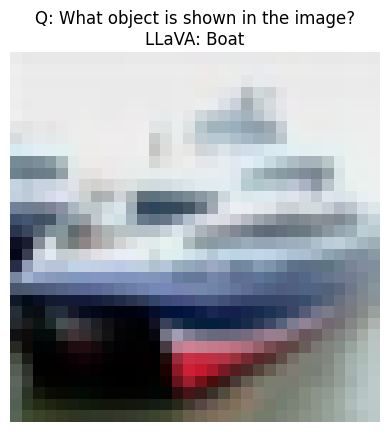

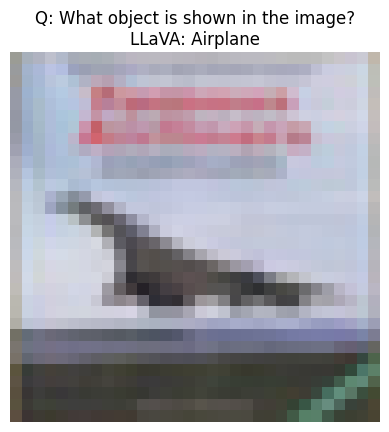

In [28]:
test_ids = [0, 1, 2]

for img_id in test_ids:
    image = sample_images[img_id]
    question = df[df['image_id'] == img_id].iloc[0]['question']

    answer = predict_llava(image, question)

    plt.imshow(image)
    plt.axis('off')
    plt.title(f"Q: {question}\nLLaVA: {answer}")
    plt.show()

## 7. Сравнение результатов

Теперь сравним все три подхода на одних и тех же примерах.

### Задание 7.1: Соберите результаты всех моделей

Что нужно сделать:
- Для каждого примера из датасета получите предсказания от всех трёх моделей
- Создайте сравнительную таблицу
- Проанализируйте, где какая модель работает лучше

In [29]:
results = {
    'Image ID': [],
    'Question': [],
    'True Answer': [],
    'ResNet+T5': [],
    'CLIP': [],
    'LLaVA': []
}

candidate_answers = list(answer_vocab.keys())

for _, row in df.iterrows():
    image_id = row['image_id']
    image = sample_images[image_id]
    question = row['question']
    true_answer = row['answer']

    baseline_pred = predict_baseline(image_id, question)
    clip_pred = predict_clip(image, question, candidate_answers)
    llava_pred = predict_llava(image, question)

    results['Image ID'].append(image_id)
    results['Question'].append(question)
    results['True Answer'].append(true_answer)
    results['ResNet+T5'].append(baseline_pred)
    results['CLIP'].append(clip_pred)
    results['LLaVA'].append(llava_pred)

results_df = pd.DataFrame(results)
results_df


,Image ID,Question,True Answer,ResNet+T5,CLIP,LLaVA
0,0,What object is shown in the image?,cat,yes,yes,The image shows a cat.
1,0,Is there a cat in the image?,yes,yes,yes,"Yes, there is a cat in the image."
2,1,What object is shown in the image?,ship,yes,ship,Boat
3,1,Is there a ship in the image?,yes,yes,automobile,"Yes, there is a ship in the image."
4,2,What object is shown in the image?,airplane,yes,airplane,Airplane
5,2,Is there a airplane in the image?,yes,yes,automobile,Yes
6,3,What object is shown in the image?,frog,yes,frog,A frog is shown in the image.
7,3,Is there a frog in the image?,yes,yes,frog,"No, there is no frog in the image. The image f..."
8,4,What object is shown in the image?,automobile,yes,automobile,The image shows a car.
9,4,Is there a automobile in the image?,yes,yes,automobile,"Yes, there is a white automobile in the image."


### Задание 7.2: Проанализируйте результаты

Что нужно сделать:
- Посчитайте accuracy для каждой модели
- Опишите сильные и слабые стороны каждого подхода
- Приведите примеры, где модели ошибаются или дают разные ответы

In [31]:
def calculate_accuracy(predictions, true_answers):
    correct = 0
    total = len(true_answers)

    for pred, true in zip(predictions, true_answers):
        if isinstance(pred, str) and isinstance(true, str):
            if true.lower() in pred.lower():
                correct += 1
        else:
            if pred == true:
                correct += 1

    return correct / total


In [32]:
baseline_acc = calculate_accuracy(
    results_df['ResNet+T5'],
    results_df['True Answer']
)

clip_acc = calculate_accuracy(
    results_df['CLIP'],
    results_df['True Answer']
)

llava_acc = calculate_accuracy(
    results_df['LLaVA'],
    results_df['True Answer']
)

print("\nТочность моделей:")
print(f"ResNet+T5: {baseline_acc:.2%}")
print(f"CLIP: {clip_acc:.2%}")
print(f"LLaVA: {llava_acc:.2%}")



Точность моделей:
ResNet+T5: 50.00%
CLIP: 50.00%
LLaVA: 75.00%


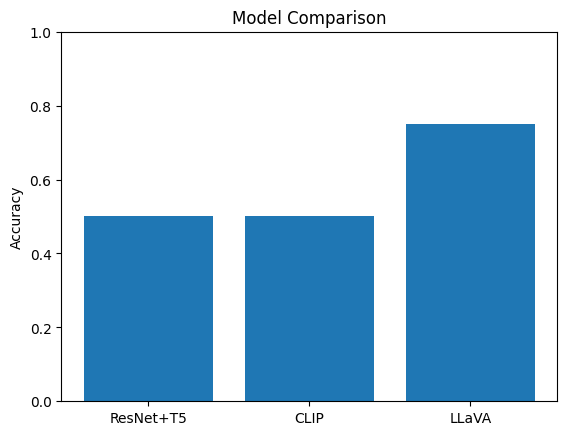

In [33]:
models = ['ResNet+T5', 'CLIP', 'LLaVA']
accuracies = [baseline_acc, clip_acc, llava_acc]
plt.bar(models, accuracies)
plt.ylabel('Accuracy')
plt.title('Model Comparison')
plt.ylim([0, 1])
plt.show()

### Выводы (заполните после экспериментов):

**Baseline (ResNet + T5)**:
- Сильные стороны:

Простая архитектура, быстро обучается, полный контроль над словарём ответов.
- Слабые стороны:

Плохо обобщает на новые формулировки, сильно зависит от размера датасета, низкая точность.

**CLIP:**
- Сильные стороны:

Не требует обучения, хорошо распознаёт объекты, устойчив к переформулировкам вопросов.
- Слабые стороны:

Ограничен списком возможных ответов, плохо справляется со сложными и абстрактными вопросами.


**LLaVA:**
- Сильные стороны:

Лучшее качество ответов, понимает контекст вопроса, генерирует осмысленные текстовые ответы.
- Слабые стороны:

Большой размер модели, высокая потребность в памяти и вычислительных ресурсах.



**Общие наблюдения:**


Генеративные мультимодальные модели (LLaVA) лучше справляются с контекстными и сложными вопросами, тогда как CLIP эффективен для простых zero-shot задач, а supervised baseline требует значительно больше данных для достижения сопоставимого качества.

**Мнения о домашке:**

Хорошо помогает понять работу разных мультимодальных моделей